## Linear Regression 

Models a relationship between a dependent variable and one or more independent variables with a linear equation. We can easily find the best fit line using the least squares method, where we take the sum of the squared differences between observed values and predicted values, and mimimise it. We will first do this, and then try using gradient descent instead to get to the same result.

In [77]:
#pip install -r requirements.txt

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_diabetes
from IPython.display import clear_output, display


In [79]:
# The data to be used - we will use the diabetes dataset from sklearn. 
diabetes = load_diabetes(as_frame=True)
# for simplicity, we will just use one feature - the BMI (body mass index) feature. We will try to predict the disease progression after one year based on this feature.
X = diabetes.data[["bmi"]].values
y = diabetes.target.values

Predicted values with initial line: [[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]]


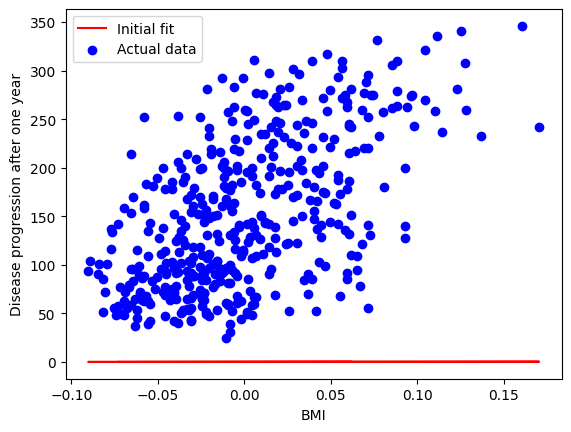

Initial mean squared error: 29074.48416289593


In [80]:
initial_y_intercept = 0
initial_gradient = 1

# calculate mean squared error for the initial line
y_pred_initial = (X * initial_gradient) + initial_y_intercept
print(f"Predicted values with initial line: {y_pred_initial[:5]}")

plt.plot(X, y_pred_initial, color="red", label="Initial fit")
plt.scatter(X, y, color="blue", label="Actual data")
plt.xlabel("BMI")
plt.ylabel("Disease progression after one year")
plt.legend()
plt.show()

initial_mean_sq_error = np.mean((y_pred_initial - y)**2)
print(f"Initial mean squared error: {initial_mean_sq_error}")

Best gradient (slope): 949.4353
Best y-intercept: 152.1335
Best-fit mean squared error: 3890.4566


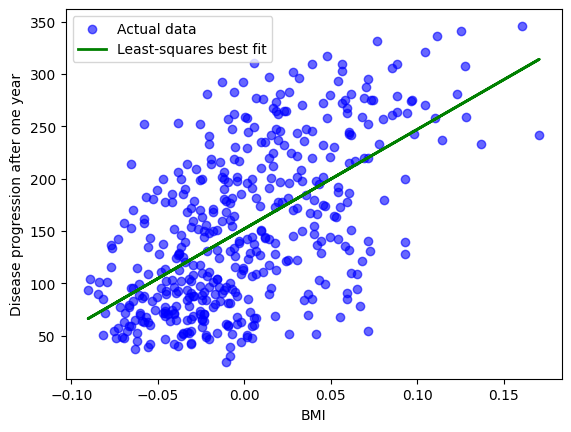

In [81]:
# we need to minimise the mean squared error.

# Step 1: Flatten X so we can do simple 1D calculations
x = X.flatten()

# Step 2: Compute means of x and y
x_mean = np.mean(x)
y_mean = np.mean(y)

# Step 3: Compute the least-squares slope (gradient)
# m = sum((x - x̄)(y - ȳ)) / sum((x - x̄)^2)
best_gradient = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

# Step 4: Compute the least-squares intercept
# b = ȳ - m * x̄
best_y_intercept = y_mean - best_gradient * x_mean

# Step 5: Predict y values using the best-fit line
y_pred_best = best_gradient * x + best_y_intercept

# Step 6: Compute mean squared error for the best-fit line
best_mean_sq_error = np.mean((y - y_pred_best) ** 2)

print(f"Best gradient (slope): {best_gradient:.4f}")
print(f"Best y-intercept: {best_y_intercept:.4f}")
print(f"Best-fit mean squared error: {best_mean_sq_error:.4f}")

# Step 7: Visualize data and the optimal least-squares line
plt.scatter(x, y, color="blue", alpha=0.6, label="Actual data")
plt.plot(x, y_pred_best, color="green", linewidth=2, label="Least-squares best fit")
plt.xlabel("BMI")
plt.ylabel("Disease progression after one year")
plt.legend()
plt.show()

## Gradient descent

Not all models can just use least squares. Now we will do the same thing but with gradient descent, which also works with logistic regression and other stuff. We will start with the same data, and then we will try to predict the same thing, but using gradient descent instead of least squares.

Our slope is:

$$
    y = mx + c
$$

Our loss function is MSE:

$$
    MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - (mx_i + c))^2
$$

where $y_i$ is the true value and $\hat{y}_i$ is the predicted value. We want to minimise this loss function by updating our parameters $m$ and $c$ in the direction of the negative gradient:

So, we need to derive twice, once with respect to $m$ and once with respect to $c$. This will give us the formulas of the gradients with respect to $m$ and $c$:
$$
    \frac{\partial MSE}{\partial m} = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - (mx_i + c))
$$
$$
    \frac{\partial MSE}{\partial c} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - (mx_i + c))
$$

KeyboardInterrupt: 

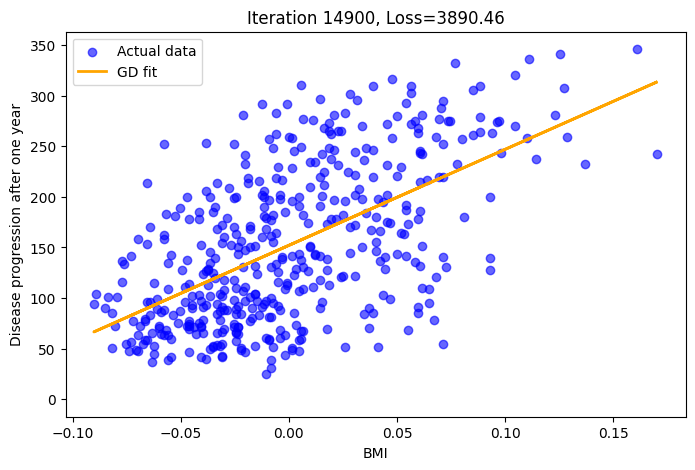

In [84]:
learning_rate = 0.1 # how big of a step we take in the direction of the negative gradient
max_iterations = 100000 # terminate if iterations reached
min_step_size = 1e-6 # terminate if step size is less, consider converged

# again we will use MSE
def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# initialize parameters
y_intercept = 0
gradient = 1

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color="blue", alpha=0.6, label="Actual data")
line, = ax.plot(x, np.zeros_like(x), color="orange", linewidth=2, label="GD fit")
ax.set_xlabel("BMI")
ax.set_ylabel("Disease progression after one year")
ax.legend()

for iteration in range(max_iterations):
    # make predictions
    y_pred = (x * gradient) + y_intercept
    
    # compute gradients
    error = y_pred - y
    gradient_y_intercept = 2 * np.mean(error)
    gradient_slope = 2 * np.mean(error * x)
    
    # update parameters
    new_y_intercept = y_intercept - (learning_rate * gradient_y_intercept)
    new_gradient = gradient - (learning_rate * gradient_slope)
    
    if iteration % 100 == 0:
        line.set_ydata(y_pred)
        ax.set_title(f"Iteration {iteration}, Loss={np.mean(error**2):.2f}")
        clear_output(wait=True)
        display(fig)
    
    # check for convergence
    step_size = np.sqrt((new_y_intercept - y_intercept) ** 2 + (new_gradient - gradient) ** 2)
    
    if step_size < min_step_size:
        print(f"Converged after {iteration} iterations.")
        break
    
    y_intercept, gradient = new_y_intercept, new_gradient
    
print(f"Final gradient (slope): {gradient:.4f}")
print(f"Final y-intercept: {y_intercept:.4f}")
print(f"Final mean squared error: {compute_loss(y, (x * gradient) + y_intercept):.4f}")
    
    

## What about with with all the features?

Before we had one feature m and one intercept c. Now we have multiple features, so we will have multiple slopes and one intercept. We can represent this with matrices:
$$
    \hat{y} = Xw + c
$$

The gradients will be 
$$
    \frac{\partial MSE}{\partial w} = -\frac{2}{n} X^T (y - (Xw + c))
$$
$$
    \frac{\partial MSE}{\partial c} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - (Xw + c))
$$

In [85]:
# The data to be used - we will use the diabetes dataset from sklearn. 
diabetes = load_diabetes(as_frame=True)
X = diabetes.data.values
y = diabetes.target.values

learning_rate = 0.1 # how big of a step we take in the direction of the negative gradient
max_iterations = 100000 # terminate if iterations reached
min_step_size = 1e-6 # terminate if step size is less, consider converged

# again we will use MSE
def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# initialize parameters
y_intercept = 0
weights = np.zeros(X.shape[1]) # one weight per feature

for iteration in range(max_iterations):
    # make predictions
    y_pred = X.dot(weights) + y_intercept
    
    # compute gradients
    error = y_pred - y
    gradient_y_intercept = 2 * np.mean(error)
    gradient_weights = 2 * X.T.dot(error) / len(y)
    
    # update parameters
    new_y_intercept = y_intercept - (learning_rate * gradient_y_intercept)
    new_weights = weights - (learning_rate * gradient_weights)
    
    # check for convergence
    step_size = np.sqrt((new_y_intercept - y_intercept) ** 2 + np.sum((new_weights - weights) ** 2))
    
    if step_size < min_step_size:
        print(f"Converged after {iteration} iterations.")
        break
    
    y_intercept, weights = new_y_intercept, new_weights
    
print(f"Final y-intercept: {y_intercept:.4f}")
print(f"Final weights: {weights}")
print(f"Final loss: {compute_loss(y, X.dot(weights) + y_intercept):.4f}")

Final y-intercept: 152.1335
Final weights: [  -7.613792   -237.14817775  525.94375675  322.08370419 -274.26213975
   65.05177889 -129.73108409  112.38776129  557.91416458   69.50345617]
Final loss: 2870.0125
